![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

 ## Roberto Fernández Sevilla

## 0. Imports 

### 0.1. General libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [4]:
from upvfab_design_tools import MMI_EME, DC_EME

In [5]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
#dos guias identicas con un espacio entre ellas, el gap. El campo evanescente sufre un acoplo en la otra guia. Contra más cerca más acoplo. 
#el mmi es una sección multimodal de guia de onda. A más ancho más modos se propagan. La interferencia entre modos, se generan puntos nulos, máximos y mínimmos de transferencia
#generando el sel-imagin, la interferencia entre distintos modos que se propagan en el MMI. 

#Para el directional coupler utilizamos la longitud de batido. Longitud de Lpi es la longitud necesaria para que la energia de la guia de la izquierda pasara completamente a la guia de la derecha.
#Dependiendo de la distancia física que tenga del directional coupler, respecto a esa distancia Lpi veremos cuanto acoplo tenemos. Lpi para te y tm es diferente. 

In [6]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 600*nm # Student. Gap between waveguides 600nm de gap
wg_width = 1.2 # Student. Core waveguides width 1.2um de ancho de guia

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()
# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605177889  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1881 [00:00<?, ?it/s]

------- Pameters -------
MMI length 94.0274
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.0012', '0.9570']
Ratio over OUTs ['0.0013', '0.9987']


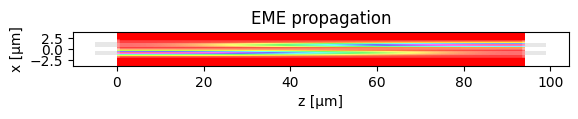

In [6]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = L_pi # Since we use the same library for propagation simulations of MMI and DC  #
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

In [ ]:
#vemos que la luz entra por un puerto y sale por el otro

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


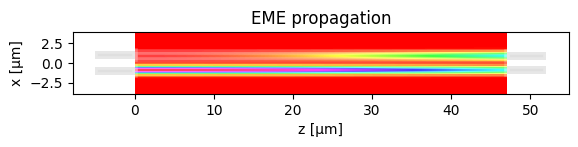

In [20]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2
#con la mitad de Lpi se transfiere la mitad de la energía.
m.L_MMI =0.5* L_pi # Since we use the same library for propagation simulations of MMI and DC  # 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

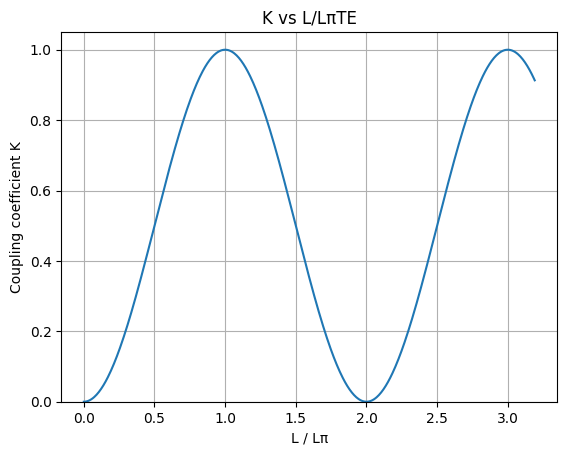

----- TE Coupling Results -----
Lπ (TE) = 94.0274 µm

K = 0.25  →  L/Lπ = 0.3333  →  L = 31.3425 µm
K = 0.50  →  L/Lπ = 0.5000  →  L = 47.0137 µm
K = 0.75  →  L/Lπ = 0.6667  →  L = 62.6850 µm
K = 1.00  →  L/Lπ = 1.0000  →  L = 94.0274 µm


In [29]:
#L/LpiTE 
L_pi = 94.02742605176876  # µm
L = np.linspace(0, 300, 600) #para hacer un barrido 
K = np.sin(0.5 * np.pi * (L / L_pi))**2 

x = L / L_pi   # Esto es L/Lpi para plotearlo

plt.figure()
plt.plot(x, K)
plt.xlabel("L / Lπ")
plt.ylabel("Coupling coefficient K")
plt.title("K vs L/LπTE")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

K_targets = [0.25, 0.50, 0.75, 1.00]

print("----- TE Coupling Results -----")
print(f"Lπ (TE) = {L_pi:.4f} µm\n")

for Kt in K_targets:
    L_norm = (2/np.pi) * np.arcsin(np.sqrt(Kt))  # L/Lpi
    L_real = L_norm * L_pi
    print(f"K = {Kt:.2f}  →  L/Lπ = {L_norm:.4f}  →  L = {L_real:.4f} µm")

In [ ]:
#Vemos que para L = Lpi = 94.02742605176876 que es el valor calculado anteriormente tenemos acoplo del 100%
#por otro lado en 0 y en 2Lpi vemos que el acoplo es 0.
#alrededor de 0.3 Lpi tendríamos un 20% de acoplo
# y alrededor de 0.7Lpi un 80% de acoplo

In [25]:
##ahora para el modo TM
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 600*nm # Student. Gap between waveguides 600nm de gap
wg_width = 1.2 # Student. Core waveguides width 1.2um de ancho de guia

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

m.polarization = "TM" # por defecto sacaba la del TE

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()
# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  52.333166163349475  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


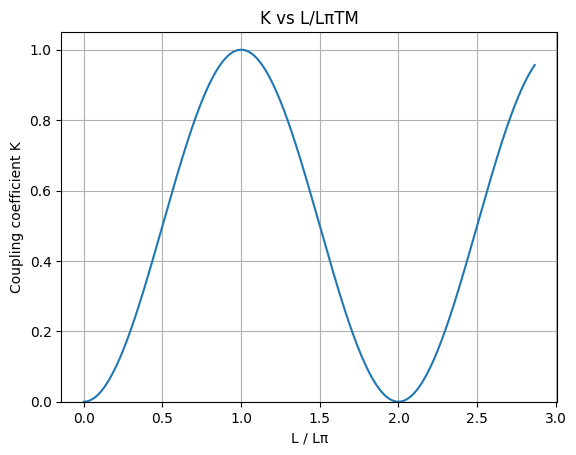

----- TM Coupling Results -----
Lπ (TM) = 52.3332 µm

K = 0.25  →  L/Lπ = 0.3333  →  L = 17.4444 µm
K = 0.50  →  L/Lπ = 0.5000  →  L = 26.1666 µm
K = 0.75  →  L/Lπ = 0.6667  →  L = 34.8888 µm
K = 1.00  →  L/Lπ = 1.0000  →  L = 52.3332 µm


In [27]:
#L/LpiTM 
L_pi = 52.333166163347904  # µm
L = np.linspace(0, 150, 600) #para hacer un barrido 
K = np.sin(0.5 * np.pi * (L / L_pi))**2 

x = L / L_pi   # Esto es L/Lpi para plotearlo

plt.figure()
plt.plot(x, K)
plt.xlabel("L / Lπ")
plt.ylabel("Coupling coefficient K")
plt.title("K vs L/LπTM")
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

K_targets = [0.25, 0.50, 0.75, 1.00]

print("----- TM Coupling Results -----")
print(f"Lπ (TM) = {L_pi:.4f} µm\n")

for Kt in K_targets:
    L_norm = (2/np.pi) * np.arcsin(np.sqrt(Kt))  # L/Lpi
    L_real = L_norm * L_pi
    print(f"K = {Kt:.2f}  →  L/Lπ = {L_norm:.4f}  →  L = {L_real:.4f} µm")

In [ ]:
##Voy a ver el Lpi necesario para cada GAP entre 600nm y 1600nm con saltos de 100 nm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1892.467412412244  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/37849 [00:00<?, ?it/s]

------- Pameters -------
MMI length 1892.4674
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6642
Excess loss [dB] =  1.7769
------------------------
Power over OUTs:  ['0.0001', '0.6641']
Ratio over OUTs ['0.0001', '0.9999']


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/src/upvfab_design_tools/eme.py:527: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  ax.pcolormesh(z_m, x_m, self.intensity_z, cmap="hsv")


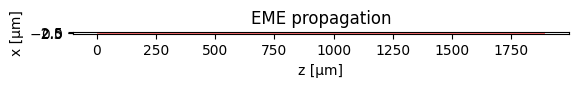

In [10]:
wg_gap = 1600*nm # Student. Gap between waveguides 600nm de gap
wg_width = 1.2 # Student. Core waveguides width 1.2um de ancho de guia

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()
# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2
#con la mitad de Lpi se transfiere la mitad de la energía.
m.L_MMI = L_pi # Since we use the same library for propagation simulations of MMI and DC  # 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

## LO.3. Parallel uncoupled waveguides

In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

#Wavelength 1.55 µm, width 1.0 µm, gap to be found for uncoupled wvgs
#Paste 𝐾 vs gap for 10 mm wvgs to be uncoupled


In [ ]:
#Wavelength 1.55 µm, width 1.0 µm, gap to be found for uncoupled wvgs

In [ ]:
#PRUEBAS DEEP WAVEGUIDE

In [7]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 3500*nm # Student. Gap between waveguides 600nm de gap
wg_width = 1.0 # Student. Core waveguides width 1.2um de ancho de guia

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()
# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  145655.90521101988  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [8]:
L = 10000  # µm
K = np.sin(0.5 * np.pi * (L / L_pi))**2
print(K)

0.01158508642229924


In [5]:
L = 10000  # µm
wg_width = 1.0

wg_N = 2

K_values = []   # aquí guardaremos K
gap_values = [] 
gaps = np.linspace(3500, 4000, 3) * nm
for wg_gap in gaps:

    m = DC_EME()

    m.MMI_num_modes = 12
    m.DC_wg_gap = wg_gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N

    # calcular modos
    m.find_all_modes()

    # obtener Lpi
    L_pi = m.get_L_pi()

    # calcular K
    K = np.sin(0.5 * np.pi * (L / L_pi))**2

    # guardar resultados
    K_values.append(K)
    gap_values.append(wg_gap/nm)


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic

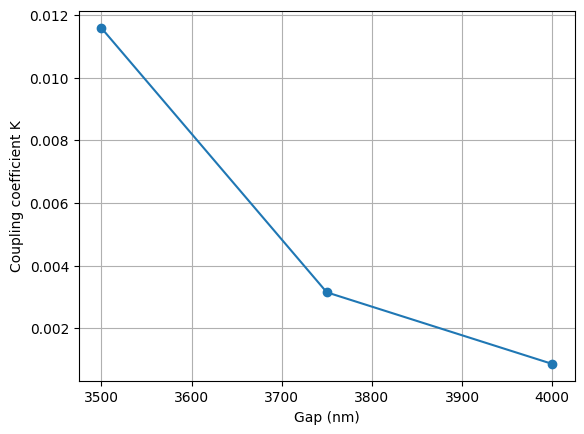

In [6]:
plt.plot(gap_values, K_values, 'o-')
plt.xlabel("Gap (nm)")
plt.ylabel("Coupling coefficient K")
plt.grid(True)
plt.show()

In [9]:
L = 10000  # µm
wg_width = 1.0

wg_N = 2

K_values = []   # aquí guardaremos K
gap_values = [] 
gaps = np.linspace(3500, 3600, 10) * nm
for wg_gap in gaps:

    m = DC_EME()

    m.MMI_num_modes = 12
    m.DC_wg_gap = wg_gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N

    # calcular modos
    m.find_all_modes()

    # obtener Lpi
    L_pi = m.get_L_pi()

    # calcular K
    K = np.sin(0.5 * np.pi * (L / L_pi))**2

    # guardar resultados
    K_values.append(K)
    gap_values.append(wg_gap/nm)


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/rober/PRACT_2_COUPLERS/pic

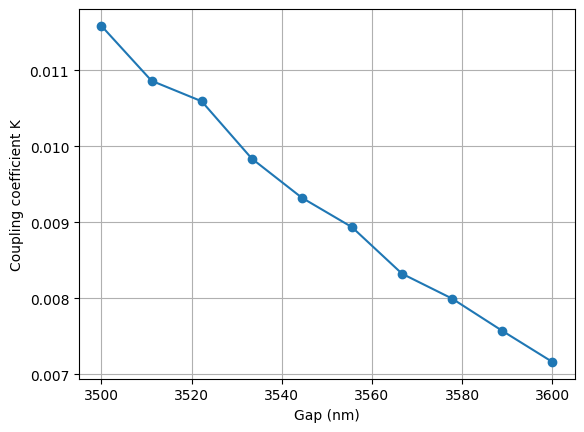

In [8]:
plt.plot(gap_values, K_values, 'o-')
plt.xlabel("Gap (nm)")
plt.ylabel("Coupling coefficient K")
plt.grid(True)
plt.show()

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

In [ ]:
#cuadno queramos diseñar un mmi nos encontraremos con este tipo de tablas. Haremos uno de interferencia simetrica. La diferencia entre interferencia pareada
#o interferencia simétrica, para la pareada hay que ubicar las entradas de manera que al propagar los modos, solo los modos pares se propagan porque en los modos impares
#las partes positivas con las negativas se anulan. Con la simetrica lo mismo para los pares. 

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [ ]:
# LA POSICION DE LAS ENTRADAS DEBE SER EL ANCHO DE LA ENTRADA ENTRE 6 
#LAS ENTRADADAS ESTARAN EN +1.1, -1.1 
#PARA SABER LA LONGITUD LO QUE NECESITO ES SABER DONDE ESTÁ LA PRIMERA IMAGEN , QUE SERÁN DOS IMAGENES, QUE SERÁ LPI / 2 
#TENGO 6.6um, CALCULO Lpi, y entonces como queremos dos salidas haremos que tenga distancia Lpi/2, para que sea 2x2, para que se divida en dos imagenes iguales 
# a la salida

In [51]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
                    #deberemos simular muchos modos, 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
print("L_pi/2 = ", L_pi/2,  " µm") #para tener un replica conde tengamos 2 salidas

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607257643  µm
L_pi/2 =  34.51799303628822  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [ ]:
#tendremos que usar una distancia física de 34.51 um

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


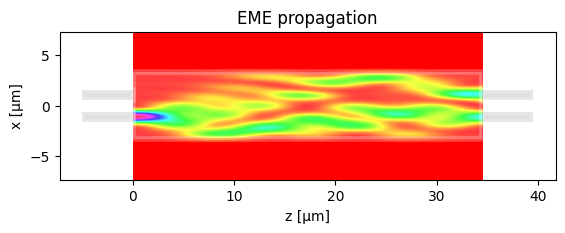

In [52]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT 2 entradas
m.n_OUT = 2 # STUDENT 2 salidas

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2 # STUDENT

# Run propagation
m.propagation()

In [ ]:
#0.4dB de pérdidas no es acepatable. Es una pérdida considerable, que en cascada daría muchas péridas. 

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


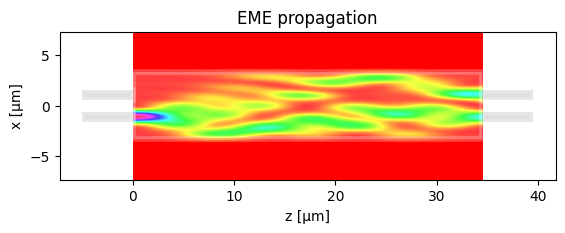

In [36]:
dy = 0.0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = 0 # STUDENT

# Run propagation
m.propagation()

In [ ]:
#asi está igual

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/670 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -1.0000
IO wg width 1.0000
IO wg width increment 0.1000
------------------------
Total power IN coupled 0.9569
Total OUT power: 0.8987
Excess loss [dB] =  0.4641
------------------------
Power over OUTs:  ['0.4451', '0.4536']
Ratio over OUTs ['0.4953', '0.5047']


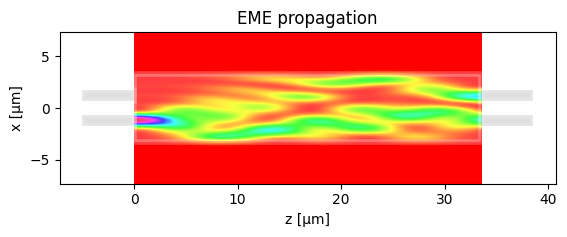

In [50]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT # las separamos con el parámetro dy

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1 # STUDENT aumentamos distancia mmi

# Run propagation
m.propagation()

In [ ]:
#ver el excess loss 

#Buscar tener menor pérdidas de exceso y tener una relación de división mejor

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/684 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.3000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9162
Excess loss [dB] =  0.3800
------------------------
Power over OUTs:  ['0.4670', '0.4492']
Ratio over OUTs ['0.5097', '0.4903']


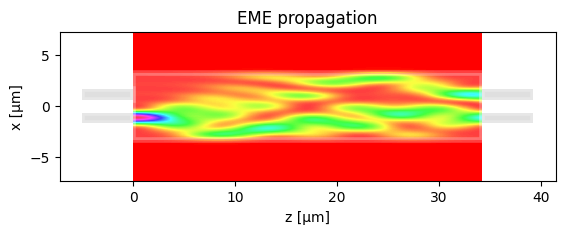

In [145]:

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6]) + np.array([-dy, dy]) # STUDENT # las separamos con el parámetro dy

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.3# STUDENT aumentamos distancia mmi

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

In [ ]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.2 # STUDENT aumentamos 0.1 um más

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607254912  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9646
Total OUT power: 0.9262
Excess loss [dB] =  0.3330
------------------------
Power over OUTs:  ['0.4682', '0.4580']
Ratio over OUTs ['0.5055', '0.4945']


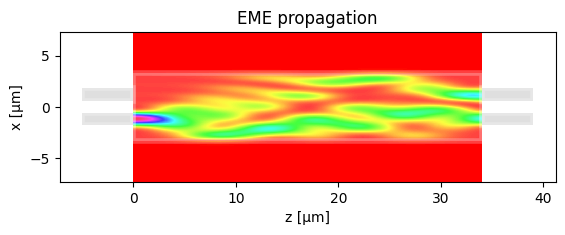

In [148]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

In [ ]:
#CON LOS VALORES DE AJUSTE ESTOS NOS HA DADO MUY BUENOS RESULTADOS 

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/686 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.2000
IO wg width 1.0000
IO wg width increment 0.2000
------------------------
Total power IN coupled 0.9687
Total OUT power: 0.9379
Excess loss [dB] =  0.2786
------------------------
Power over OUTs:  ['0.4793', '0.4586']
Ratio over OUTs ['0.5110', '0.4890']


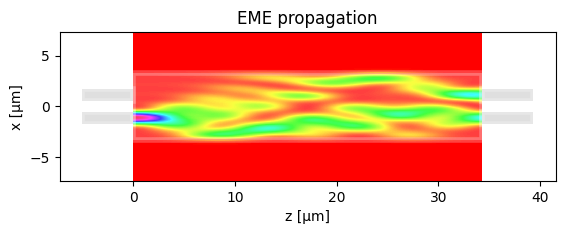

In [161]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2  # STUDENT
m.dL_MMI = -0.2 # STUDENT

# Run propagation
m.propagation()

In [ ]:
#esto son mejores valores

In [223]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.6 # STUDENT aumentamos 0.1 um más

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255596  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/682 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.4000
IO wg width 1.0000
IO wg width increment 0.6000
------------------------
Total power IN coupled 0.9888
Total OUT power: 0.9781
Excess loss [dB] =  0.0963
------------------------
Power over OUTs:  ['0.4980', '0.4801']
Ratio over OUTs ['0.5092', '0.4908']


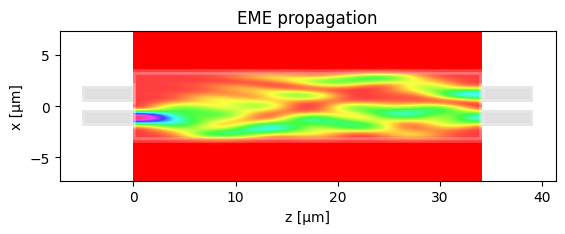

In [224]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.06
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1/6, 1/6])+ np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2  # STUDENT

m.dL_MMI = -0.4# STUDENT

# Run propagation
m.propagation()

In [ ]:
#Hemos obtenido un valor de menos de 0.1 dB de ecess loss. 

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [ ]:
#seleccionar un ancho de guia multimodal que pueda contener las 4 guias. IMPORTANTE. Partir del 6.6 e ir un poco superior. 

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**


In [266]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width =6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 30 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
                    #deberemos simular muchos modos, 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")
print("L_pi/2 = ", (3* L_pi)/(4*4),  " µm") #para tener un replica conde tengamos 4 salidas

/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255869  µm
L_pi/2 =  12.944247388604754  µm


/home/rober/PRACT_2_COUPLERS/pic-upv-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/259 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.9442
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9667
Total OUT power: 0.9590
Excess loss [dB] =  0.1819
------------------------
Power over OUTs:  ['0.2224', '0.2571', '0.2569', '0.2226']
Ratio over OUTs ['0.2319', '0.2681', '0.2679', '0.2321']


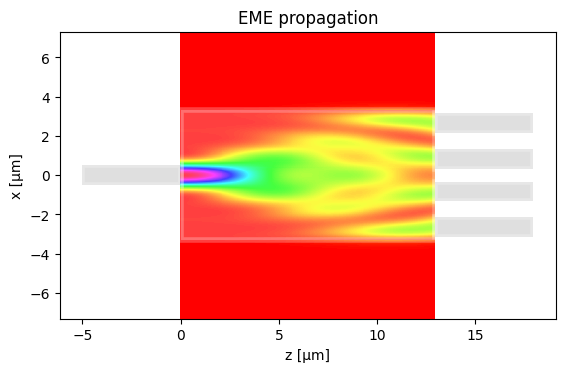

In [275]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1 # STUDENT 2 entradas
m.n_OUT = 4 # STUDENT 2 salidas

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width * np.array([0]) # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1.6/4, -0.5/4,0.5/4, 1.6/4 ])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (3* L_pi)/(4*4) # STUDENT

# Run propagation
m.propagation()

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/274 [00:00<?, ?it/s]

------- Pameters -------
MMI length 12.9442
MMI length increment 0.7800
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9667
Total OUT power: 0.9462
Excess loss [dB] =  0.2399
------------------------
Power over OUTs:  ['0.2373', '0.2359', '0.2357', '0.2374']
Ratio over OUTs ['0.2507', '0.2493', '0.2491', '0.2509']


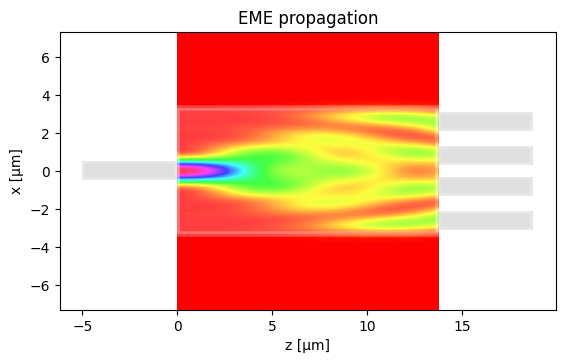

In [318]:
#editamos para mejorar excess loss
dy1 = -0.04
dy2 = -0.015
# MMI I/O waveguide positions (check class slides for type of MMI)
 # STUDENT
m.OUT_WVG_positions = m.MMI_width * np.array([-1.6/4, -0.5/4,0.5/4, 1.6/4 ])  + np.array([-dy1, -dy2, dy2, dy1])  # STUDENT

# MMI length (check class slides for type of MMI)

m.dL_MMI =0.78# STUDENT

# Run propagation
m.propagation()

In [ ]:
# hemos mejorado el ratio over outputs, empeorando un poco las pérdidas de excesoque teníamos antes. 

## Extra - Exercises

In [ ]:
##ejercicios EXTRA

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = ... * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


In [16]:
gap_values = np.arange(200,2600,200)
Lpi_TE = []
Lpi_TM = []
for gap in gap_values:

    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=1.55,
        core_width=(1.0,1.0),
        gap=gap * nm,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = deep_dcoupler_cs.n_eff
# el orden de los modos los he visto en el siguiente ejercicio
    # TE
    n_1_TE = neff[0]
    n_2_TE = neff[1]
    Lpi_TE.append(1.55/(2*(n_1_TE-n_2_TE)))

    # TM
    n_1_TM = neff[2]
    n_2_TM = neff[3]
    Lpi_TM.append(1.55/(2*(n_1_TM-n_2_TM)))

2026-03-12 11:13:22.880 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_19fc40f5ad5a09a8.npz.
2026-03-12 11:13:22.884 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_266d67620f0948f9.npz.
2026-03-12 11:13:22.887 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b966fe1ac7f3af0a.npz.
2026-03-12 11:13:22.890 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_f8167db7728a9ebb.npz.
2026-03-12 11:13:22.893 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b0f701e58db4a1bf.npz.
2026-03-12 11:13:22.896 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_de78bc7bac7ad149.npz.
2026-03-12 11:13:22.899 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_69d8430ee5b848c9.npz.
2026-03-12 11:13:22.902 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

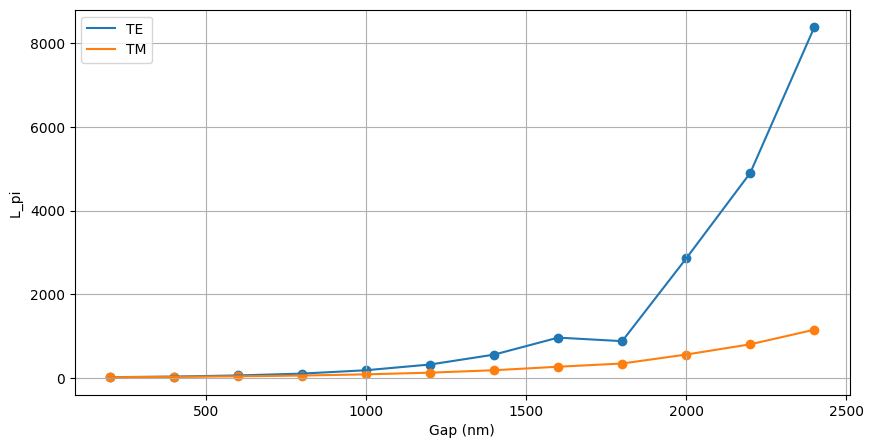

In [17]:
plt.figure(figsize=(10,5))

plt.plot(gap_values, Lpi_TE,label='TE')
plt.scatter(gap_values, Lpi_TE)

plt.plot(gap_values, Lpi_TM,label='TM')
plt.scatter(gap_values, Lpi_TM)

plt.xlabel("Gap (nm)")
plt.ylabel("L_pi ")
plt.grid()
plt.legend()
plt.show()

In [12]:
gap_values = np.arange(200,2600,200)
Lpi_TE = []
Lpi_TM = []
for gap in gap_values:

    shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=1.55,
        core_width=(1.0,1.0),
        gap=gap * nm,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=6,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = shallow_dcoupler_cs.n_eff
# el orden de los modos los he visto en el siguiente ejercicio
    # TE
    n_1_TE = neff[0]
    n_2_TE = neff[1]
    Lpi_TE.append(1.55/(2*(n_1_TE-n_2_TE)))

    # TM
    n_1_TM = neff[3]
    n_2_TM = neff[5]
    Lpi_TM.append(1.55/(2*(n_1_TM-n_2_TM)))

2026-03-12 11:08:27.297 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_b03a12d775e892b5.npz.
2026-03-12 11:08:27.303 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_ab36ae5dddc655ae.npz.
2026-03-12 11:08:27.305 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_675892dba083647f.npz.
2026-03-12 11:08:27.309 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_51d5f34b3245baa6.npz.
2026-03-12 11:08:27.312 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7fe9ad70d046c535.npz.
2026-03-12 11:08:27.315 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_1f47d479c97bf1df.npz.
2026-03-12 11:08:27.318 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_7156e6cde61dfc59.npz.
2026-03-12 11:08:27.320 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

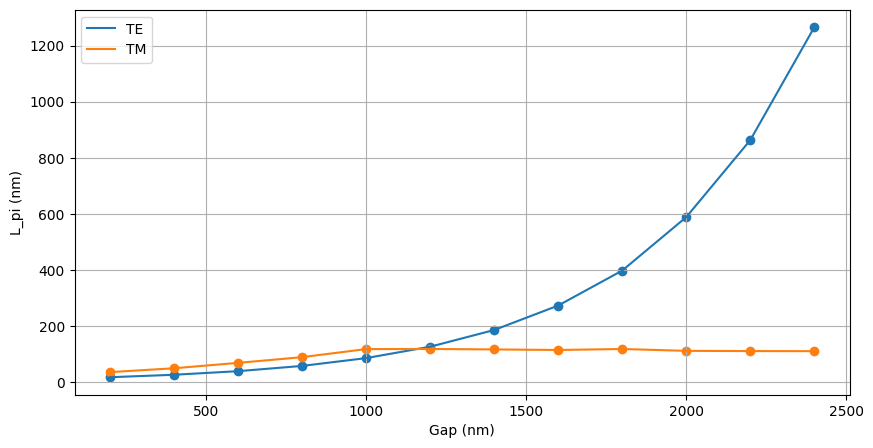

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(gap_values, Lpi_TE,label='TE')
plt.scatter(gap_values, Lpi_TE)

plt.plot(gap_values, Lpi_TM,label='TM')
plt.scatter(gap_values, Lpi_TM)

plt.xlabel("Gap (nm)")
plt.ylabel("L_pi ")
plt.grid()
plt.legend()
plt.show()

### E2. Directional coupler wavelength dependence

2026-03-12 11:13:57.224 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_87463f91b7f75735.npz.
[[1.59983288+0.00011221j 1.58873802+0.00010682j 1.53284653+0.00018275j
  1.51477886+0.00018274j]
 [1.59808275+0.00011265j 1.58663455+0.00010723j 1.53161059+0.00018243j
  1.51314382+0.00018253j]
 [1.59635152+0.00011307j 1.58454408+0.00010763j 1.53039729+0.00018211j
  1.5115316 +0.00018232j]
 [1.59463909+0.00011349j 1.58246664+0.00010804j 1.52920623+0.00018177j
  1.50994206+0.0001821j ]
 [1.59294539+0.00011389j 1.58040226+0.00010843j 1.52803702+0.00018143j
  1.50837506+0.00018187j]
 [1.59127033+0.00011429j 1.57835095+0.00010883j 1.52688928+0.00018107j
  1.50683044+0.00018163j]
 [1.58961381+0.00011468j 1.57631275+0.00010921j 1.52576264+0.00018071j
  1.50530807+0.00018138j]
 [1.58797574+0.00011506j 1.57428768+0.0001096j  1.52465673+0.00018034j
  1.50380779+0.00018113j]
 [1.586356  +0.00011543j 1.57227578+0.00010998j 1.52357116+0.00017996j
  1.50232946+0.000180

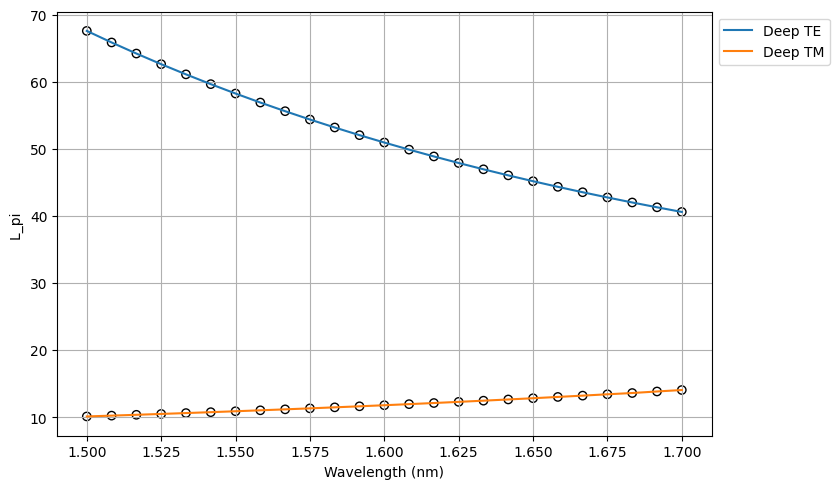

In [18]:
##deep
wavelength  = np.linspace(1.5,1.7,25) # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
print (deep_neff)
te_modes = deep_dcoupler_cs.fraction_te
tm_modes = deep_dcoupler_cs.fraction_tm
print (te_modes)
print(tm_modes)


# TE
n_1_TE = deep_neff[:, 0]
n_2_TE  = deep_neff[:, 1]

# TM
n_1_TM = deep_neff[:, 2]
n_2_TM  = deep_neff[:, 3]


L_pi_TE = wavelength/(2*(n_1_TE-n_2_TE)) # STUDENT code here
L_pi_TM = wavelength / (2 * (n_2_TE - n_2_TM))
plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TE, label='Deep TE')
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TM, label='Deep TM')

plt.xlabel("Wavelength (nm)")
plt.ylabel("L_pi ")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

2026-03-12 11:14:15.115 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_207c4fd5c5561331.npz.
[[1.63744105+9.71946913e-05j 1.61972356+9.49018257e-05j
  1.54922185+1.45500548e-04j 1.54834464+1.77952900e-04j
  1.54365261+1.48992509e-04j 1.52781121+1.77929437e-04j]
 [1.63593498+9.74316936e-05j 1.61787895+9.52379292e-05j
  1.54811799+1.45350895e-04j 1.5471215 +1.77644548e-04j
  1.54253095+1.48692460e-04j 1.52626341+1.77868046e-04j]
 [1.63444291+9.76622413e-05j 1.61604783+9.55713296e-05j
  1.54702758+1.45193279e-04j 1.54591769+1.77329103e-04j
  1.54141679+1.48381107e-04j 1.5247373 +1.77796448e-04j]
 [1.63296473+9.78863930e-05j 1.61423025+9.59020708e-05j
  1.54595012+1.45027007e-04j 1.54473288+1.77009057e-04j
  1.54030982+1.48058194e-04j 1.52323281+1.77713468e-04j]
 [1.63150031+9.81042090e-05j 1.61242623+9.62301963e-05j
  1.54488516+1.44852005e-04j 1.54356672+1.76685818e-04j
  1.53920974+1.47723533e-04j 1.52174987+1.77618656e-04j]
 [1.63004951+9.83157510

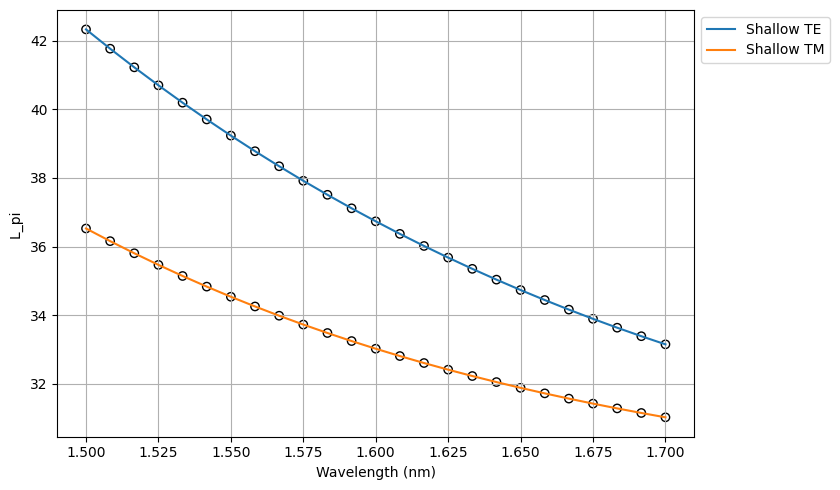

In [19]:
##shallow
wavelength = wavelength = np.linspace(1.5,1.7,25) # STUDENT code goes here

shallow_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide. 
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=6, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

shallow_neff = shallow_dcoupler_cs.n_eff
print (shallow_neff)
te_modes = shallow_dcoupler_cs.fraction_te
tm_modes = shallow_dcoupler_cs.fraction_tm
print (te_modes)
print(tm_modes)


# TE
n_1_TE = shallow_neff[:, 0]
n_2_TE  = shallow_neff[:, 1]

# TM
n_1_TM = shallow_neff[:, 3]
n_2_TM  = shallow_neff[:, 5]


L_pi_TE = wavelength/(2*(n_1_TE-n_2_TE)) # STUDENT code here
L_pi_TM = wavelength / (2 * (n_1_TM - n_2_TM))
plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TE, label='Shallow TE')
plt.scatter(wavelength, L_pi_TM, edgecolors='k', facecolors='none', label='__nolegend__')
plt.plot(wavelength, L_pi_TM, label='Shallow TM')

plt.xlabel("Wavelength (nm)")
plt.ylabel("L_pi ")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 